# Data Understanding & Structure Review

**Reasoning**:
To import the useful Python Libraries which would be further used in the EDA (Exploratory Data Analysis Process)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Reasoning**:
To import the dataset CSV file into the notebook, we use pandas library



In [ ]:
df = pd.read_csv('Nexora_Bank_Dataset.csv')

**Reasoning**:
To display the first 5 rows of the `df` DataFrame, I will use the `.head()` method, which is a standard way to get a quick overview of the data's structure and content.



In [ ]:
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


**Reasoning**:
To display the DataFrame's information as requested, I will use the `.info()` method on the `df` DataFrame.



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


## Display Descriptive Statistics



**Reasoning**:
To generate the descriptive statistics as outlined in the instructions, I will use the `.describe()` method on the DataFrame `df`.



In [ ]:
df.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## Check for Missing Values


**Reasoning**:
As outlined in the instructions, I will now execute the code to calculate and display the number of missing values for each column in the `df` DataFrame.



In [ ]:
df.isnull().sum()

,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0


## Delete 'IsActiveMember' Column

**Reasoning**:
To delete the `IsActiveMember` column from the DataFrame, I will use the `.drop()` method with `columns=['IsActiveMember']` and `inplace=True` to modify the DataFrame directly. After deletion, I will display the first 5 rows of the DataFrame to confirm the column has been removed.

In [ ]:
df.drop(columns=['IsActiveMember'], inplace=True)

print("DataFrame after deleting 'IsActiveMember' column:")
display(df.head())

DataFrame after deleting 'IsActiveMember' column:


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,79084.10,0


## Create Age Category Column


Create a new column named `AgeCategory` based on the `Age` column with the following criteria:
*   18-35 years: Young
*   35-60 years: Adults
*   60+ years: Senior Citizen

**Reasoning**:
To categorize the `Age` column into `AgeCategory` (Young, Adults, Senior Citizen), I will define the bins and labels for each age group. Then, I will use the `pd.cut()` function to apply these categories to the `Age` column and create the new `AgeCategory` column. This method is efficient for segmenting numerical data into discrete intervals.

In [ ]:
bins = [18, 35, 60, np.inf]
labels = ['Young', 'Adults', 'Senior Citizen']

df['AgeCategory'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

print("Value counts for the new 'AgeCategory' column:")
display(df['AgeCategory'].value_counts())

print("First 5 rows with the new 'AgeCategory' column:")
display(df.head())

Value counts for the new 'AgeCategory' column:


,count
AgeCategory,
Adults,5795
Young,3679
Senior Citizen,526


First 5 rows with the new 'AgeCategory' column:


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,EstimatedSalary,Exited,AgeCategory
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,101348.88,1,Adults
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,112542.58,0,Adults
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,113931.57,1,Adults
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,93826.63,0,Adults
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,79084.10,0,Adults


## Create Credit Score Category Column

Create a new column named `CreditScoreCategory` based on the `CreditScore` column with the following criteria:
*   800-850: Excellent
*   740-799: Very Good
*   670-739: Good
*   580-669: Fair
*   Below 580: Poor

**Reasoning**:
To categorize the `CreditScore` column into `CreditScoreCategory` (Excellent, Very Good, Good, Fair, Poor), I will define the bins and labels for each score range. Then, I will use the `pd.cut()` function to apply these categories to the `CreditScore` column and create the new `CreditScoreCategory` column. This method is efficient for segmenting numerical data into discrete intervals.

In [ ]:
bins = [0, 580, 670, 740, 800, np.inf]
labels = ['Poor', 'Fair', 'Good', 'Very Good', 'Excellent']

df['CreditScoreCategory'] = pd.cut(df['CreditScore'], bins=bins, labels=labels, right=False)

print("Value counts for the new 'CreditScoreCategory' column:")
display(df['CreditScoreCategory'].value_counts())

print("First 5 rows with the new 'CreditScoreCategory' column:")
display(df.head(15))

Value counts for the new 'CreditScoreCategory' column:


,count
CreditScoreCategory,
Fair,3331
Good,2428
Poor,2362
Very Good,1224
Excellent,655


First 5 rows with the new 'CreditScoreCategory' column:


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,EstimatedSalary,Exited,AgeCategory,CreditScoreCategory
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,101348.88,1,Adults,Fair
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,112542.58,0,Adults,Fair
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,113931.57,1,Adults,Poor
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,93826.63,0,Adults,Good
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,79084.10,0,Adults,Excellent
5,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,149756.71,1,Adults,Fair
6,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,10062.80,0,Adults,Excellent
7,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,119346.88,1,Young,Poor
8,15792365,He,501,France,Male,44,4,142051.07,2,0,74940.50,0,Adults,Poor
9,15592389,H?,684,France,Male,27,2,134603.88,1,1,71725.73,0,Young,Good


In [ ]:
churn_rate = df['Exited'].mean() * 100
print(f"The overall churn rate is: {churn_rate:.2f}%")

The overall churn rate is: 20.37%


**Reasoning**:
Churned customers have significantly higher mean age → Age is a churn indicator

In [ ]:
df.groupby('Exited')['Age'].mean()

,Age
Exited,
0,37.408389
1,44.837997


**Reasoning**:
Germany shows 30% churn vs France 15% → Geography matters.

In [ ]:
pd.crosstab(df['Geography'], df['Exited'], normalize='index')

Exited,0,1
Geography,,
France,0.838452,0.161548
Germany,0.675568,0.324432
Spain,0.833266,0.166734


**Reasoning**:
To effectively check for outliers, I will first identify all numerical columns in the DataFrame. Then, I will iterate through these columns to create a box plot for each using `seaborn.boxplot`. This visualization method clearly displays the distribution of the data, the median, quartiles, and any points that lie beyond the interquartile range, which are considered potential outliers. To support the visual inspection, I will also calculate and print the first quartile (Q1), third quartile (Q3), and the Interquartile Range (IQR) for each numerical column. Additionally, I'll define the upper and lower bounds for outlier detection using the 1.5*IQR rule.

--- CustomerId ---
Q1: 15628528.25
Q3: 15753233.75
IQR: 124705.50
Lower Bound (Outliers): 15441470.00
Upper Bound (Outliers): 15940292.00


--- CreditScore ---
Q1: 584.00
Q3: 718.00
IQR: 134.00
Lower Bound (Outliers): 383.00
Upper Bound (Outliers): 919.00


--- Age ---
Q1: 32.00
Q3: 44.00
IQR: 12.00
Lower Bound (Outliers): 14.00
Upper Bound (Outliers): 62.00


--- Tenure ---
Q1: 3.00
Q3: 7.00
IQR: 4.00
Lower Bound (Outliers): -3.00
Upper Bound (Outliers): 13.00


--- Balance ---
Q1: 0.00
Q3: 127644.24
IQR: 127644.24
Lower Bound (Outliers): -191466.36
Upper Bound (Outliers): 319110.60


--- NumOfProducts ---
Q1: 1.00
Q3: 2.00
IQR: 1.00
Lower Bound (Outliers): -0.50
Upper Bound (Outliers): 3.50


--- HasCrCard ---
Q1: 0.00
Q3: 1.00
IQR: 1.00
Lower Bound (Outliers): -1.50
Upper Bound (Outliers): 2.50


--- EstimatedSalary ---
Q1: 51002.11
Q3: 149388.25
IQR: 98386.14
Lower Bound (Outliers): -96577.10
Upper Bound (Outliers): 296967.45


--- Exited ---
Q1: 0.00
Q3: 0.00
IQR: 0.00
Lower Bound

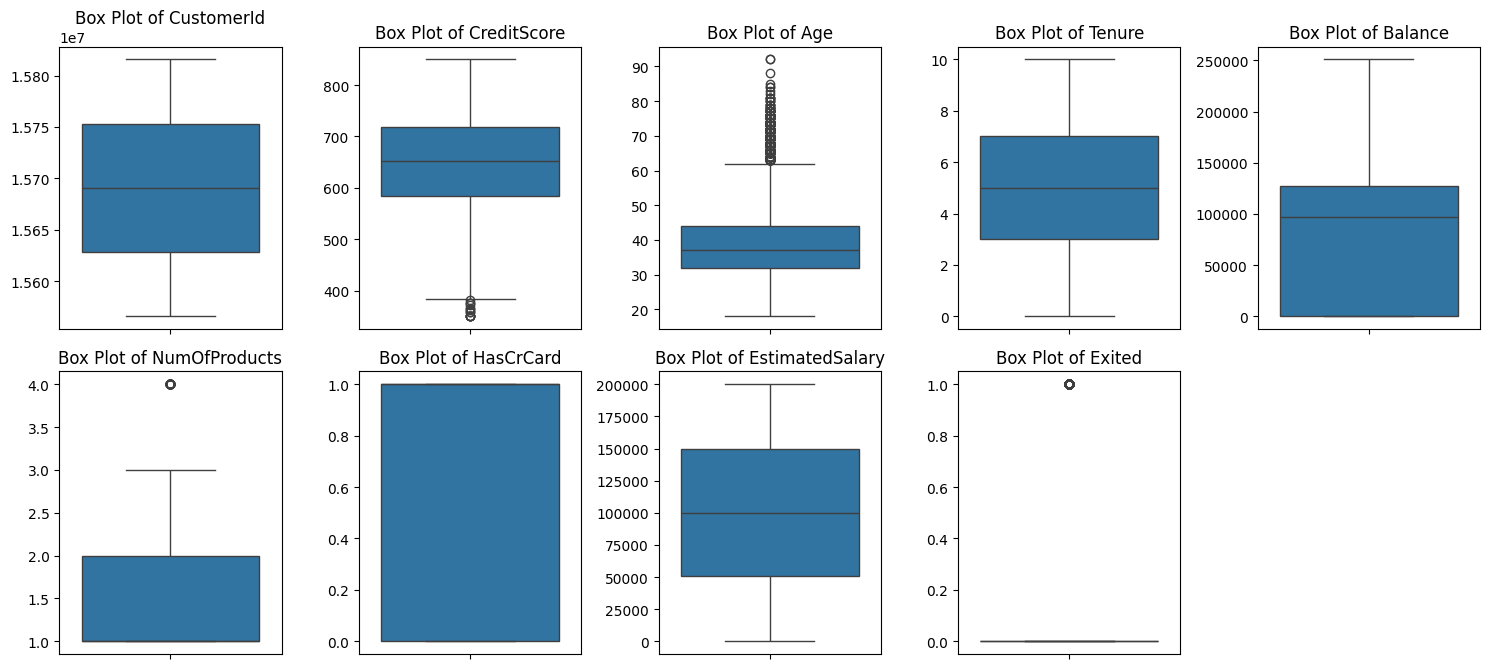

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, column in enumerate(numerical_cols, 1):
    plt.subplot(3, 5, i) # Adjust subplot grid as needed
    sns.boxplot(y=df[column])
    plt.title(f'Box Plot of {column}')
    plt.ylabel('')

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print(f"--- {column} ---")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Lower Bound (Outliers): {lower_bound:.2f}")
    print(f"Upper Bound (Outliers): {upper_bound:.2f}")
    print("\n")

plt.tight_layout()
plt.show()

## Visualize Credit Score Distribution by Credit Card Ownership

Create two separate histograms (or one faceted histogram) of the `CreditScore`, one for customers who have a credit card (`HasCrCard` = 1) and another for those who do not (`HasCrCard` = 0). This will allow for a visual comparison of their credit score distributions. The plot will include appropriate titles, labels, and a legend to differentiate the groups.


**Reasoning**:
To visualize the distribution of CreditScore based on credit card ownership, I will create a histogram using seaborn's histplot function. This will allow for a clear comparison between customers with and without credit cards, fulfilling all the plotting requirements specified in the instructions.



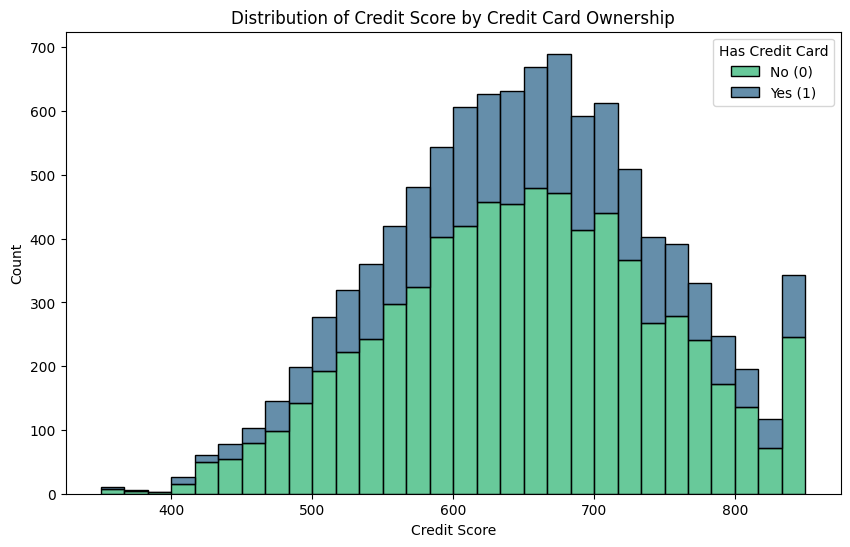

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='CreditScore', hue='HasCrCard', multiple='stack', palette='viridis', bins=30)
plt.title('Distribution of Credit Score by Credit Card Ownership')
plt.xlabel('Credit Score')
plt.ylabel('Count')
plt.legend(title='Has Credit Card', labels=['No (0)', 'Yes (1)'])
plt.show()

## Visualize Relationship Between Geography and CreditScoreCategory

Create a bar chart to visualize the distribution of `CreditScoreCategory` for each `Geography`. This will help understand if there's a difference in credit score categories across countries.

**Reasoning**:
To visualize the relationship between two categorical variables, `Geography` and `CreditScoreCategory`, a countplot from the seaborn library is highly effective. I will use `sns.countplot` with `x='Geography'` and `hue='CreditScoreCategory'` to display the count of each credit score category within each geography, allowing for easy comparison. I will also add appropriate titles and labels for clarity.

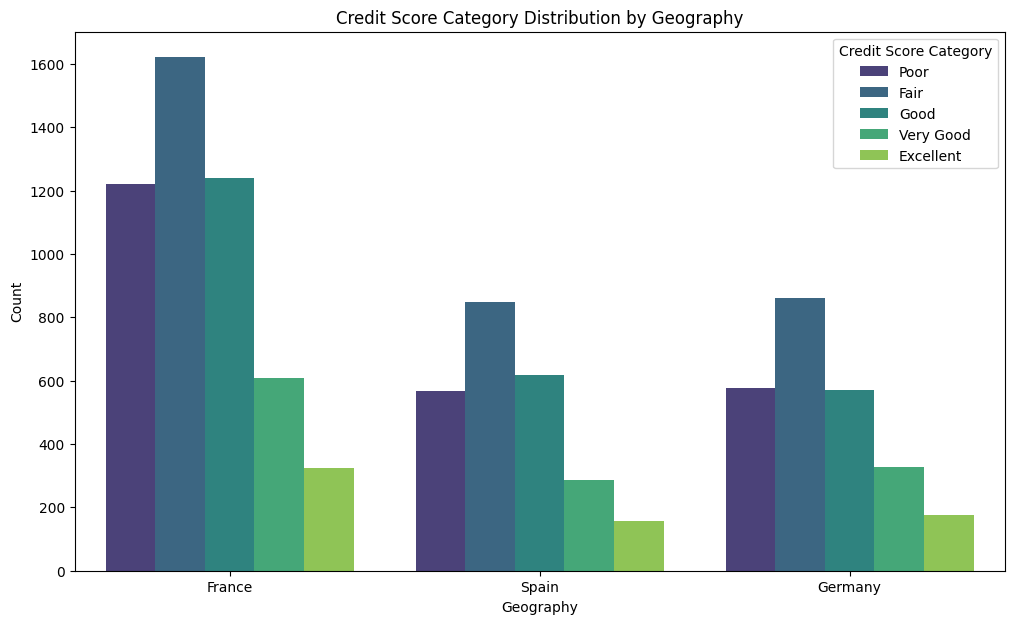

In [ ]:
plt.figure(figsize=(12, 7))
sns.countplot(data=df, x='Geography', hue='CreditScoreCategory', palette='viridis')
plt.title('Credit Score Category Distribution by Geography')
plt.xlabel('Geography')
plt.ylabel('Count')
plt.legend(title='Credit Score Category')
plt.show()

## Create Correlation Heatmap


Generate a heatmap to visualize the correlations between numerical columns in the DataFrame.

**Reasoning**:
To visualize the correlation between numerical columns, I will first select all numerical columns from the DataFrame using `df.select_dtypes(include=np.number)`. Then, I will compute the pairwise correlation between these columns using the `.corr()` method. Finally, I will use `seaborn.heatmap` to display the correlation matrix as a heatmap, with annotations to show the correlation values and a diverging color map for better interpretation.

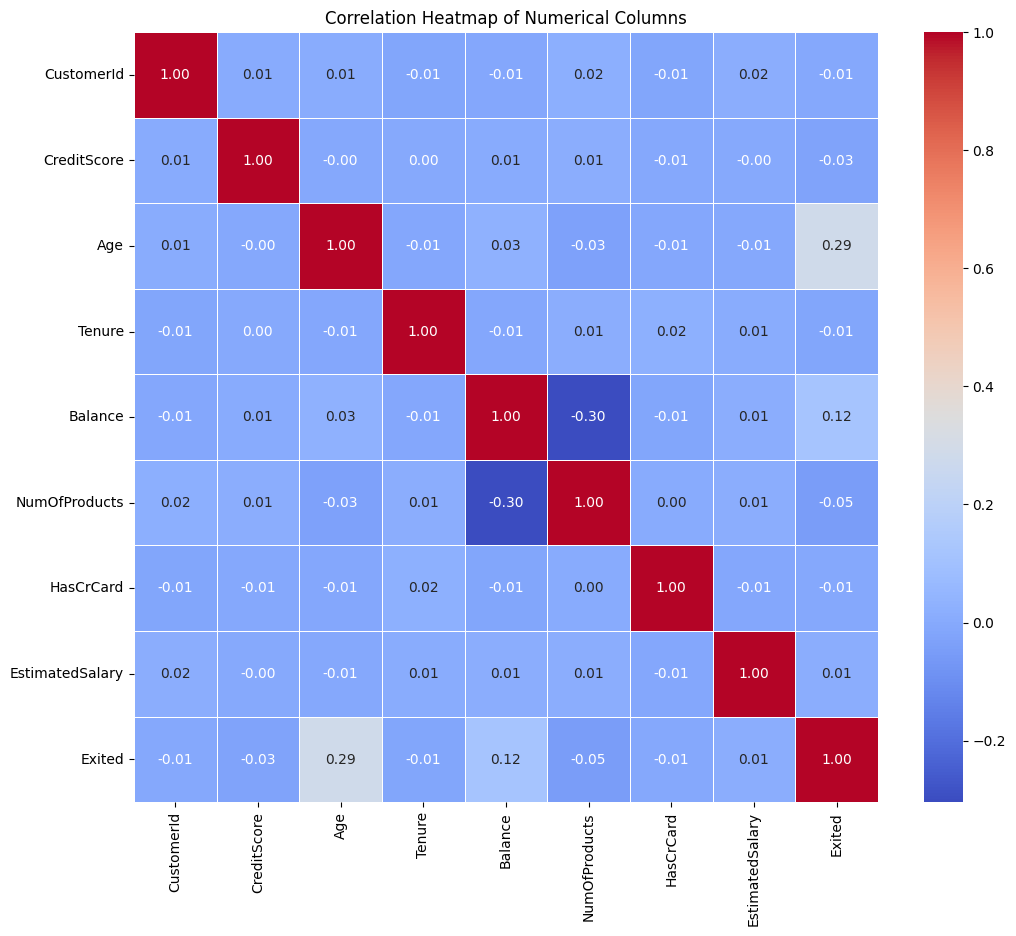

In [ ]:
numerical_df = df.select_dtypes(include=np.number)
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Columns')
plt.show()

## Visualize Relationship Between Credit Score and Exited

### Subtask:
Create a box plot to visualize the distribution of `CreditScore` for customers who exited (`Exited`=1) and those who did not (`Exited`=0). This will help understand if there's a noticeable difference in credit scores between these two groups.

**Reasoning**:
To visualize the distribution of `CreditScore` for customers who exited versus those who did not, a `seaborn.boxplot` is an effective choice. It will display the median, quartiles, and potential outliers of credit scores for each group, allowing for a clear comparison of their distributions. I will set the x-axis to 'Exited' and the y-axis to 'CreditScore', and add an appropriate title and axis labels.

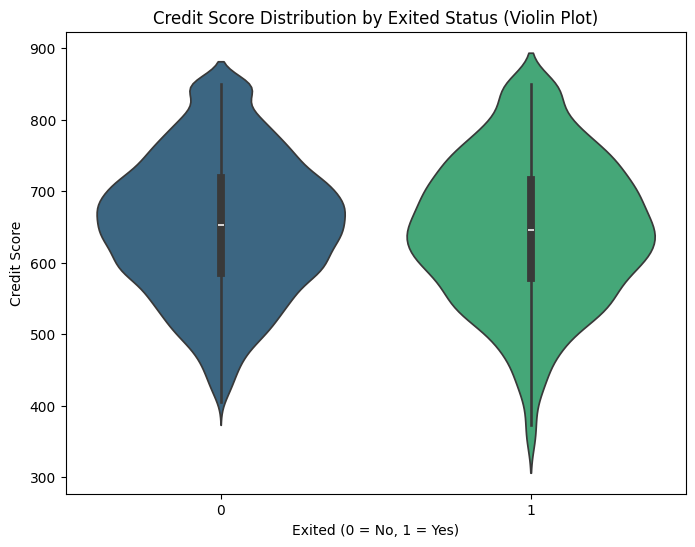

In [ ]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='Exited', y='CreditScore', data=df, palette='viridis', hue='Exited', legend=False)
plt.title('Credit Score Distribution by Exited Status (Violin Plot)')
plt.xlabel('Exited (0 = No, 1 = Yes)')
plt.ylabel('Credit Score')
plt.show()

## Export Cleaned DataFrame to CSV

Save the current DataFrame (`df`) to a new CSV file named 'Bank_Churn_cleaned.csv'. The index will not be included in the exported file.


**Reasoning**:
To save the cleaned DataFrame `df` to a CSV file named 'Bank_Churn_cleaned.csv' without including the index, I will use the `.to_csv()` method and set the `index` parameter to `False`.



In [ ]:
df.to_csv('Nexora_Bank_Churn_Cleaned.csv', index=False)
print("DataFrame successfully exported to 'Bank_Churn_cleaned.csv'")

DataFrame successfully exported to 'Bank_Churn_cleaned.csv'
